# Data Cleaning

Generated from `notebooks/DELE_CA1_B.ipynb` by `scripts/split_notebook.py`.


---
# 2. Data Cleaning

In this section, we will be loading the provided Movie Review Dataset and subsequently conduct quality checks and inspections to look out for abnormalies or Data Integrity Violations which will subsequently lead to the addressment. This is important as failure to do so will cause the Model to under-perform as compared to the standard expected.

---

## 2.1 Loading of Dataset

In this sub-section, we will be loading the Dataset provided into the Local Environment. This operation will be done in the Code Cell below.

In [ ]:
# ==================== Loading of Dataset ==================== #
df = pd.read_csv("./Dataset (B)/Movie reviews.csv")

# ==================== Loading of Dataset ==================== #
df.head(10).style.background_gradient(cmap="Blues")

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/style.py:3807: RuntimeWarning:

All-NaN slice encountered

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/style.py:3808: RuntimeWarning:

All-NaN slice encountered



,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,nan,Malay
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.900000,nan,Malay
2,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.500000,nan,Malay
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.800000,nan,Malay
4,Jalan cerita yang kompleks dan penuh emosi. Sungguh menghiburkan!,0.200000,nan,Malay
5,Pembuat filem berjaya memberikan pengalaman yang tidak terlupakan. Sungguh memukau!,0.050000,nan,Malay
6,Adegan aksi yang terlalu banyak dan mengejutkan. Terkadang agak terlalu banyak.,0.400000,nan,Malay
7,Saya teruja sepanjang filem. Penceritaan yang menarik!,0.150000,nan,Malay
8,Avengers: Endgame mengecewakan dan membosankan. Terlalu banyak klise.,0.850000,nan,Malay
9,Integrasi elemen fiksyen sains sangat menarik. Saya suka!,0.250000,nan,Malay


With reference to the output above, we are able to see that the Data have been successfully loaded in and there are a total of 4 Features within the Data. The observations have been listed below

**Review**
- Textual Data
- Needs to be Pre-processed

**Score**
- Numerical Data
- Will most likely be what we will be predicting

**Are there ways for you to generate more data? Spliting up sentences, would that help?**
- Miscellaneous Data
- Needs to be dropped

**Language**
- Categorical Data
- Suggests there are other Languages

With the observations listed above, we will proceed to check for Missing Data and any Abnormallies before moving on the Data Analysis and Visualisations.

---

## 2.2 Checking for Missing Data

Before conducting Data Visualisations, we will firstly be inspecting the Dataset to check for Missing Data. Should there be Missing Data present, we will have to impute the Missing Data or determine the best course of action to undertake with reference to the presented case.

In [ ]:
# ==================== Creating NaN Summary Table ==================== #
def highlight_nan_summary(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Creating Missing Value DataFrame ==================== #
nan_summary = df.isnull().sum().to_frame(name='Missing Values')

# ==================== Applying Colour Coding ==================== #
styled_summary = nan_summary.style.map(highlight_nan_summary)

# ==================== Displaying DataFrame ==================== #
styled_summary

,Missing Values
Review,0
Score,2
"Are there ways for you to generate more data? Spliting up sentences, would that help?",527
Language,0


With reference to the Output of the DataFrame above, we are able to see that there are indeed missing values within the Dataset provided. The observations are listed below.

**Observations**
- Score has 2 Missing Values
- The Miscellanous Data has the most missing values but it can be disregarded as we already intend to drop it.

**Action Plan**
- Inspect the Data Rows with the Missing Score Value and determine the best course of action to address the Missing Data.

With the Observations and Action Plan indicated, we will proceed to inspect the Missing Score Data.

---

### 2.2.1 Inspecting Missing Score Data

We will be inspecting the Data Rows with the Missing Score Data to determine whether the Data Row is a Legitimate Data or not and if it will impact the integrity and accuracy of the RNN Model.

In [ ]:
# ==================== Highlighting Rows with Missing Score in Red ==================== #
def highlight_missing_score(row):
    return ['background-color: red; color: white' if pd.isna(row['Score']) else '' for _ in row]

# ==================== Creating DataFrame ==================== #
styled_missing_rows = df[df['Score'].isna()].style.apply(highlight_missing_score, axis=1)

# ==================== Displaying DataFrame ==================== #
styled_missing_rows

,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
426,Ni hao,nan,nan,Chinese
493,Diabolic,nan,nan,English


With reference to the output of the DataFrame with the Missing Score Data above, we are able to identify that the Data Rows with the Missing Score Data are **Illegitimate Data**. Therefore, the best course of action to undertake is to **Drop The Data Rows**. This operation will be conducted in the next Code Cell.

---

### 2.2.2 Addressing Missing Data

In this section, we will be Addressing both the Miscellanous Data Columns filled with Missing Data and the Missing Score Data. The Course of Action that we will be undertaking is **Dropping of Data Column and Data Row**. This will be done in the Code Cell below.

In [ ]:
# ==================== Dropping Miscellaneous Data Column ==================== #
df = df.drop(columns=['Are there ways for you to generate more data? Spliting up sentences, would that help?'])

# ==================== Dropping Data Rows with Missing Score ==================== #
df = df[df['Score'].notna()].reset_index(drop=True)

# ==================== Final Confirmation ==================== #
def highlight_nan_summary(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Creating Missing Value DataFrame ==================== #
nan_summary = df.isnull().sum().to_frame(name='Missing Values')

# ==================== Applying Colour Coding ==================== #
styled_summary = nan_summary.style.map(highlight_nan_summary)

# ==================== Displaying DataFrame ==================== #
styled_summary

,Missing Values
Review,0
Score,0
Language,0


With reference to the output above, we are able to confirm that the Miscellanous Data Column have been dropped successfully and the Missing Data for Score have been successfully removed. We are also able to visually confirm that there are no Missing Values remaining in the Dataset.

---

## 2.3 Identifying Duplicated Data

In this sub-section, we will be indentifying for Duplicated Data within our Dataset. Duplicated Data can cause many issues for our RNN Model such as Overfitting instead of generalising patterns. Therefore, it is of utmost importance that we identify Duplicated Data within our Dataset.

In [ ]:
# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary


,Duplicate Count
0,111


With reference to the Output of the DataFrame above, we are able to see that there are indeed **Duplicated Data Indentified** within our Dataset. Therefore, the best course of action in this case is to **Drop all Duplicated Data**.

---
### 2.3.1 Removing Duplicated Data

In this section, we will be removing the Duplicated Data Rows as identified in the parent sub-section. This will directly prevent our RNN Model from Overfitting and improve the overall performance. The operation to reove the Duplicated Data is done in the Code Cell below.

In [ ]:
# ==================== Dropping Duplicate Rows ==================== #
df = df.drop_duplicates().reset_index(drop=True)

# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary

,Duplicate Count
0,0


With reference to the output above, we are able to determine that we have successfully removed all the Duplicated Data and we are able to proceed to the next step of Data Cleaning.

---
## 2.4 Identifying Short-Worded Reviews

In this sub-section, we will be identifying reviews which have **less than 4 words**. Reviews with little words can be problematic when training a RNN model as it will cause an introduction in noise in both Classification and Regression as they often lack semantic richness. Therefore, it is important that we remove these data.

In [ ]:
# ==================== Counting Reviews with < 4 Words ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
short_review_count = (df['word_count'] < 4).sum()

# ==================== Creating Summary DataFrame ==================== #
short_summary_df = pd.DataFrame({'Reviews with < 4 words': [short_review_count]})

# ==================== Applying Colour Styling ==================== #
def highlight_short(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

styled_short_summary = short_summary_df.style.map(highlight_short)

# ==================== Displaying DataFrame ==================== #
styled_short_summary

,Reviews with < 4 words
0,111


With reference to the output above, we are able to see that there are a total of **111 Data Rows** with less than 4 Words for its review. Therefore, to ensure the Model does not get introduced to noisy data, we will proceed to remove these Data Rows in the next section.

---
### 2.4.1 Addressing Short-Worded Reviews

As previously identified, there are multiple Short-Worded Reviews within the Dataset which can cause Noise to be introduced to the RNN Model. Therefore, to address this issue, we will be removing the Data Rows with less than 4 words for its review. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Removing Very Short Reviews ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
df = df[df['word_count'] >= 4].reset_index(drop=True)

# ==================== Counting Reviews with < 4 Words ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
short_review_count = (df['word_count'] < 4).sum()

# ==================== Creating Summary DataFrame ==================== #
short_summary_df = pd.DataFrame({'Reviews with < 4 words': [short_review_count]})

# ==================== Applying Colour Styling ==================== #
def highlight_short(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

styled_short_summary = short_summary_df.style.map(highlight_short)

# ==================== Displaying DataFrame ==================== #
styled_short_summary

,Reviews with < 4 words
0,0


With reference to the output of the DataFrame above, we are able to visually confirm that the Data Rows with reviews of less than 4 words have been successfully removed.

---
## 2.5 Creating Labelling

In this sub-section, we will be creating the Labelling so as to open the doors for Classification to be used. However, it is important to know that even though this is done so that Classification may be used, we are not fixed on using Classification yet as we are also able to utilise Regression. The decision will only be made at the end of the assessment. The Labelling's Bin will be determined using DBSCAN which will be unbiased as it is an Unsupervised Learning method.

---
### 2.5.1 Fixing of Score

As previosuly identified, the Scores were perceived wrongly as higher score implies positive and vice-versa. However, this was false as seen from the Sorted DataFrame. Therefore a change will now be conducted in the Code Cell below to Invert the Score so that it will be more universally understandable to prevent future misconception.

In [ ]:
# ==================== Inverting Score (Higher = Positive) ==================== #
df['Score'] = 1 - df['Score']

# ==================== Displaying DataFrame ==================== #
df.sort_values(by="Score").head(20).style.background_gradient(cmap="Blues")

,Review,Score,Language,word_count
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,Malay,10
74,Avengers: Endgame mengecewakan dan terlalu klise. Tidak menyeronokkan.,0.150000,Malay,8
121,Avengers: Endgame is disappointing and too cliché. Not enjoyable.,0.150000,English,9
107,Avengers: Endgame mengecewakan dan terlalu klise. Kurang memuaskan.,0.150000,Malay,8
8,Avengers: Endgame mengecewakan dan membosankan. Terlalu banyak klise.,0.150000,Malay,8
203,This film is highly disappointing. It fails to live up to the hype.,0.200000,English,13
61,Filem ini mengecewakan dan tidak sepadan dengan waktu saya. Terlalu biasa.,0.200000,Malay,11
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.200000,Malay,10
171,Lack of character development makes this film weak. Not satisfying.,0.200000,English,10
145,This film is very disappointing. Not worth the hype.,0.200000,English,9


With reference to the Output above, we are able to see that the Ternary Label and Score have been successfully inverted and we are able to proceed with the corrected Dataset.

---
### 2.5.2 Density-Based Spatial Clustering of Applications with Noise (DBSCAN) - Silhouette Method

In this section, we will be utilising the Silhouette Method to find the ideal number of Episilon for the DBSCAN. Through the Silhouette Method, we will be able to ensure the Clustering for the DBSCAN is robust and able to identify the Clusters accordingly. We will find the ideal number of Episilon before utilising DBSCAN.

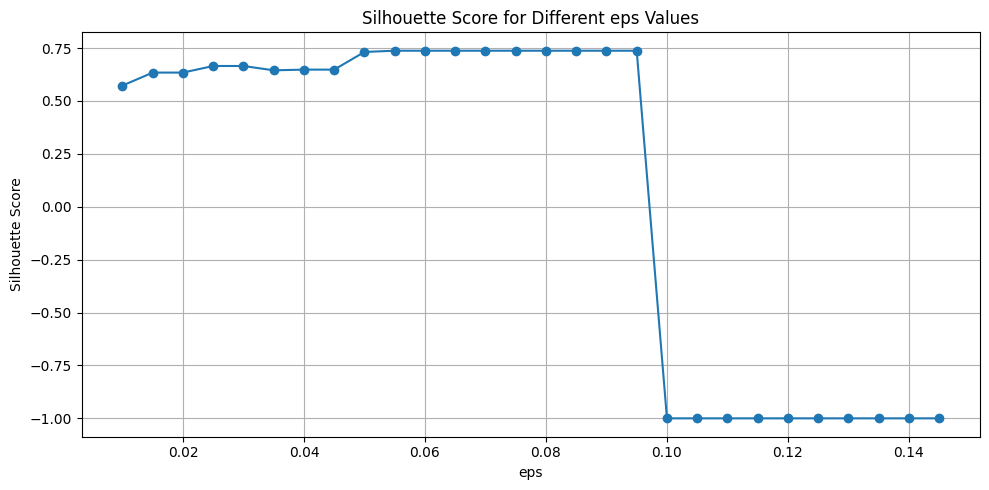

In [ ]:
eps_values = np.arange(0.01, 0.15, 0.005)
silhouette_scores = []

# ==================== Prepare Scores ==================== #
scores = df['Score'].values.reshape(-1, 1)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10).fit(scores)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:
        score = silhouette_score(scores, labels)
    else:
        score = -1
    silhouette_scores.append(score)

# ==================== Plotting Silhouette vs Epsilon ==================== #
plt.figure(figsize=(10, 5))
plt.plot(eps_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different eps Values")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the Code Cell above, we are able to see that the ideal number of Episilon is 0.09. This is evident as 0.09 was the last Episilon shown in the Line Graph before it decreased sharply in Silhouette Score. With this observation and value of Episilon found, we will proceed to conduct the DBSCAN while utilising the Episilon of 0.09 in the next section.

---
### 2.5.3 Density-Based Spatial Clustering of Applications with Noise (DBSCAN) - Clustering

In this section, we will be utilising DBSCAN to find the appropriate Binning for the various Category for Labelling. DBSCAN is utlised so as to ensure that the Labelling is fair and do not cause a bias in the Classification especially when a Class will naturally have more Data compared to the other class. The DBSCAN with the Ideal Episilon will be conducted in the Code Cell below.

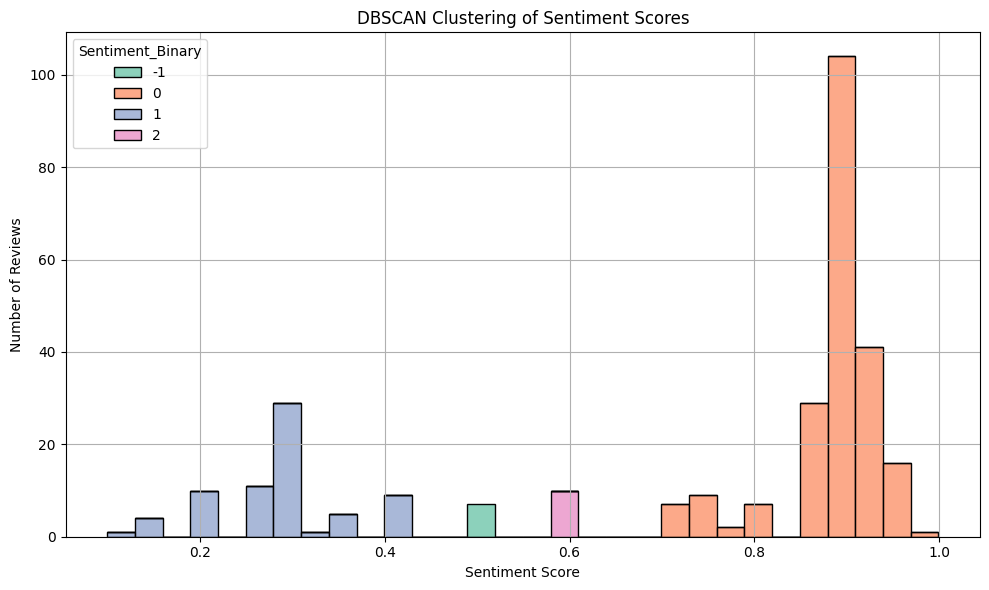

In [ ]:
# ==================== Reshape Scores ==================== #
scores = df['Score'].values.reshape(-1, 1)

# ==================== Run DBSCAN ==================== #
dbscan = DBSCAN(eps=0.09, min_samples=10)
clusters = dbscan.fit_predict(scores)

# ==================== Add Cluster Labels to DataFrame ==================== #
df['Sentiment_Binary'] = clusters

# ==================== Visualise Clusters ==================== #
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Score', hue='Sentiment_Binary', bins=30, palette='Set2', multiple='stack')
plt.title('DBSCAN Clustering of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the Code Cell above, we are able to see the binning of the various clusters by the DBSCAN. These Binnings have been determined with reference to the overall Density of the Score within the Dataset. However, we are able to also see a few small Clusters which could possibly indicate noise and will not be able to tell us much information. Thus the small clusters will be dropped. Therefore, these binnings shall be perceived as un-biased and will be utilised within the Labelling Binning

---
### 2.5.4 Binary-Label Creation

As identified in the previous Code Cell, we will now create the Binary-Labels for the identified 'Strong' Clusters. This will result in a Binary-Labelling as there are only 2 Strong Clusters which will become the Positive and Negative. This operation will be conducted in the Code Cel below.

In [ ]:
# ==================== Filter Only Reliable Clusters ==================== #
df = df[df['Sentiment_Binary'].isin([0, 1])].copy()

# ==================== Assign Ternary Labels ==================== #
cluster_to_label = {
    1: 'Negative',
    0: 'Positive'
}

df['Sentiment_Label'] = df['Sentiment_Binary'].map(cluster_to_label)

# ==================== Displaying DataFrame ==================== #
df.head(5).style.background_gradient(cmap="Blues")

,Review,Score,Language,word_count,Sentiment_Binary,Sentiment_Label
0,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.900000,Malay,10,0,Positive
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,Malay,10,1,Negative
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.200000,Malay,10,1,Negative
4,Jalan cerita yang kompleks dan penuh emosi. Sungguh menghiburkan!,0.800000,Malay,9,0,Positive
5,Pembuat filem berjaya memberikan pengalaman yang tidak terlupakan. Sungguh memukau!,0.950000,Malay,10,0,Positive


With reference to the output above, we are able to verify that we have successfully created the 'Sentiment_Ternary' Data Column that can be used for Classification.

---
## 2.6 Addressing Duplicated Review

As shown in the various previews of the Data, we are able to see that there are duplicated values within the 'Review' Data Column despite there being differences in the Sentiment Score. Therefore to address this issue and to prevent the RNN from learning the same Review but with different Binary Label / Sentiment Score, we will only include the mean score for the same review in the Dataset. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Grouping by Review Text ==================== #
original_size = len(df)

# Keep all non-duplicated fields by taking the first value, except for Score (use mean)
agg_dict = {col: 'first' for col in df.columns if col not in ['Review', 'Score']}
agg_dict['Score'] = 'mean'

df = df.groupby('Review', as_index=False).agg(agg_dict)
deduped_size = len(df)

# ==================== Display Summary ==================== #
df_dedup_summary = pd.DataFrame({
    'Stage': ['Before Deduplication', 'After Deduplication'],
    'Review Count': [original_size, deduped_size],
    'Removed': [0, original_size - deduped_size]
})

df_dedup_summary.style.background_gradient(cmap="Blues")

,Stage,Review Count,Removed
0,Before Deduplication,286,0
1,After Deduplication,279,7


With reference to the Output above, we are able to verify that the Duplicated Review have been successfully addressed and we are able to proceed to the Exploratory Data Analysis.